In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# --- 1. Load Data (all) ---
truth = pd.read_csv("mc_truth_10s.csv")
fit_results = pd.read_csv("mc_test_output.csv") 
hits = pd.read_csv("mc_hits_10s.csv")

# # # --- 1. Load Data (high) ---
# truth = pd.read_csv("mc_truth_high_pe_10s.csv")
# fit_results = pd.read_csv("mc_test_output.csv") 
# hits = pd.read_csv("mc_hits_high_pe_10s.csv")

In [78]:
def double_exp_integral(t0, t1, A_fast, rate_fast, A_slow, rate_slow):
    """
    Integral of A_fast * exp(-rate_fast * t) + A_slow * exp(-rate_slow * t)
    over [t0, t1], with support only for t >= 0.
    """
    a = max(t0, 0.0)
    b = max(t1, 0.0)
    if b <= a:
        return 0.0

    fast = A_fast / rate_fast * (np.exp(-rate_fast * a) - np.exp(-rate_fast * b))
    slow = A_slow / rate_slow * (np.exp(-rate_slow * a) - np.exp(-rate_slow * b))
    return fast + slow

def build_unit_template_on_bins(bin_edges_us,
                                pulse_time_us,
                                A_fast, rate_fast,
                                A_slow, rate_slow,
                                support_end_us=100.0):
    """
    Unit-area expected contribution on histogram bins for one pulse.
    """
    vals = np.zeros(len(bin_edges_us) - 1, dtype=float)

    # first compute raw integrals
    for i in range(len(vals)):
        left = bin_edges_us[i] - pulse_time_us
        right = bin_edges_us[i + 1] - pulse_time_us

        # optional finite support
        if left >= support_end_us:
            continue
        right_clip = min(right, support_end_us)

        vals[i] = double_exp_integral(left, right_clip,
                                      A_fast, rate_fast,
                                      A_slow, rate_slow)

    s = vals.sum()
    if s > 0:
        vals /= s
    return vals

def build_mu_expected(bin_edges_us, pulses_df,
                      A_fast, rate_fast,
                      A_slow, rate_slow,
                      support_end_us=100.0,
                      background_per_bin=0.0):
    mu = np.zeros(len(bin_edges_us) - 1, dtype=float)

    for _, row in pulses_df.iterrows():
        comp = build_unit_template_on_bins(
            bin_edges_us=bin_edges_us,
            pulse_time_us=row['time_us'],
            A_fast=A_fast,
            rate_fast=rate_fast,
            A_slow=A_slow,
            rate_slow=rate_slow,
            support_end_us=support_end_us
        )
        mu += row['amplitude_pe'] * comp

    mu += background_per_bin
    return mu

def find_coincidence_seeds_from_hits(hits, coincidence_window_us=0.05, veto_window_us=0.01):
    """
    Mimic the C++ seed finder:
    - a seed starts at hit i
    - look forward within coincidence_window_us
    - require at least one hit from a different channel
    - require total >= 2 hits
    - after accepting a seed, veto later seeds until t0 + veto_window_us
    """
    df = hits.sort_values('time_us').reset_index(drop=True)

    times = df['time_us'].to_numpy()
    chans = df['channel'].to_numpy()

    seeds = []
    next_allowed_seed_time_us = -1e99
    n = len(df)

    for i in range(n):
        t0 = times[i]
        if t0 < next_allowed_seed_time_us:
            continue

        ch0 = chans[i]
        armed = False
        total = 1

        j = i + 1
        while j < n:
            tj = times[j]
            if tj - t0 > coincidence_window_us:
                break

            if chans[j] != ch0:
                armed = True
            total += 1
            j += 1

        if armed and total >= 2:
            seeds.append(t0)
            next_allowed_seed_time_us = t0 + veto_window_us

    return np.array(seeds)

def gauss_triple_exp_integral(t0, t1, baseline, g_amp, g_mu, g_sigma, t_start, A_list, tau_list):
    """
    Analytic integral of:
    c + A_g * exp(-0.5*((t-mu)/sigma)^2) + H(t-t0) * sum(A_i * exp(-(t-t0)/tau_i))
    """
    def analytic_integral(t):
        # 1. Baseline: c * t
        term_c = baseline * t
        
        # 2. Gaussian: A * sigma * sqrt(pi/2) * erf((t-mu)/(sigma*sqrt(2)))
        term_g = g_amp * g_sigma * np.sqrt(np.pi / 2.0) * erf((t - g_mu) / (g_sigma * np.sqrt(2.0)))
        
        # 3. Triple Exponential Tail (piecewise at t_start)
        term_exps = 0.0
        if t > t_start:
            for A, tau in zip(A_list, tau_list):
                term_exps += A * tau * (1.0 - np.exp(-(t - t_start) / tau))
        
        return term_c + term_g + term_exps

    return analytic_integral(t1) - analytic_integral(t0)

def build_unit_template_on_bins(bin_edges_us, pulse_time_us, params, support_end_us=100.0):
    """
    Unit-area expected contribution using the Gaussian + Triple Exp model.
    """
    vals = np.zeros(len(bin_edges_us) - 1, dtype=float)
    
    # Extract params for readability
    c = params['baseline']
    ga_amp, ga_mu, ga_sig = params['gauss_amp'], params['gauss_mu'], params['gauss_sigma']
    t_start = params['tail_start_us']
    A_list = [params['a1'], params['a2'], params['a3']]
    tau_list = [params['tau1'], params['tau2'], params['tau3']]

    for i in range(len(vals)):
        # Shift evaluation window relative to pulse_time_us
        left = bin_edges_us[i] - pulse_time_us
        right = bin_edges_us[i + 1] - pulse_time_us

        if left >= support_end_us:
            continue
        right_clip = min(right, support_end_us)

        vals[i] = gauss_triple_exp_integral(left, right_clip, c, ga_amp, ga_mu, ga_sig, 
                                            t_start, A_list, tau_list)

    s = vals.sum()
    if s > 0:
        vals /= s
    return vals

def build_mu_expected_triple(bin_edges_us, pulses_df, params, support_end_us=100.0, background_per_bin=0.0):
    mu = np.zeros(len(bin_edges_us) - 1, dtype=float)
    for _, row in pulses_df.iterrows():
        comp = build_unit_template_on_bins(
            bin_edges_us=bin_edges_us,
            pulse_time_us=row['time_us'],
            params=params,
            support_end_us=support_end_us
        )
        mu += row['amplitude_pe'] * comp
    mu += background_per_bin
    return mu

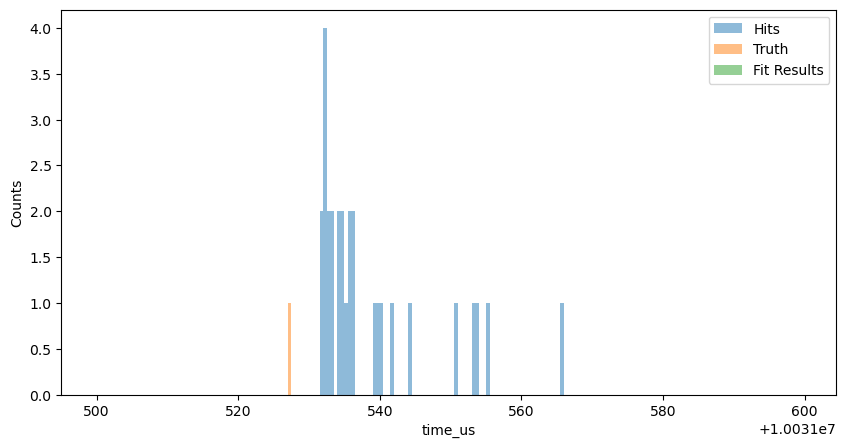

In [83]:
t0 = 10e6
tmin = 31500 + t0
tmax = 31600 + t0
bins = np.arange(tmin, tmax, 0.5)

hits_win = hits[(hits['time_us'] > tmin) & (hits['time_us'] < tmax)]
truth_win = truth[(truth['time_us'] > tmin) & (truth['time_us'] < tmax)]
fit_win = fit_results[(fit_results['time_us'] > tmin) & (fit_results['time_us'] < tmax)]

# coincidence_seeds should be a 1D array / series of seed times in absolute us
coincidence_seeds = find_coincidence_seeds_from_hits(
    hits_win,
    coincidence_window_us=0.05,
    veto_window_us=0.01
)

plt.figure(figsize=(10, 5))
plt.hist(hits_win['time_us'], bins=bins, alpha=0.5, label='Hits')
plt.hist(truth_win['time_us'], bins=bins, alpha=0.5, label='Truth')
plt.hist(fit_win['time_us'], bins=bins, alpha=0.5, label='Fit Results')

for i, s in enumerate(coincidence_seeds):
    plt.axvline(s, linestyle='--', alpha=0.3, color='red',
                label='Coincidence Seed' if i == 0 else None)

plt.legend()
plt.xlabel('time_us')
plt.ylabel('Counts')
plt.show()

C:\Users\ciyou\AppData\Local\Temp\ipykernel_28308\3449068453.py:39: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log') # Recommended for observing the tail fit


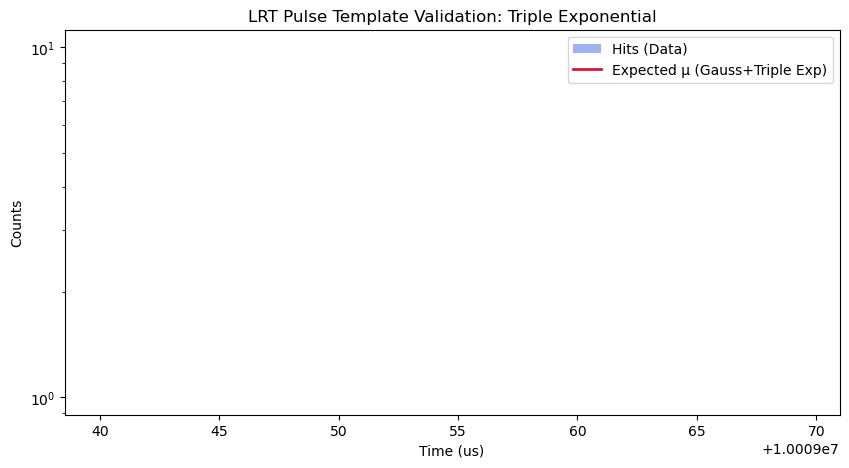

In [80]:
# 1. Setup Time Windows
t0 = 10e6
tmin = 9040 + t0
tmax = 9070 + t0
bins = np.arange(tmin, tmax, 0.5)

hits_win = hits[(hits['time_us'] > tmin) & (hits['time_us'] < tmax)]
fit_win = fit_results[(fit_results['time_us'] > tmin) & (fit_results['time_us'] < tmax)]

# 2. Define Triple Exponential Parameters
triple_params = {
    'baseline': 2.35574699e-04,
    'gauss_amp': 2.64853519e-01,
    'gauss_mu': 0.0,
    'gauss_sigma': 1.82163026e-01,
    'tail_start_us': 0.0,
    'a1': 2.96819526e-02, 'tau1': 5.0,
    'a2': 5.49622939e-02, 'tau2': 1.14242898,
    'a3': 5.19776557e-03, 'tau3': 29.3893616,
    'support_end_us': 100.0
}

# 3. Calculate Expected Counts
mu = build_mu_expected_triple(
    bin_edges_us=bins,
    pulses_df=fit_win[['time_us', 'amplitude_pe']],
    params=triple_params,
    support_end_us=triple_params['support_end_us'],
    background_per_bin=0.0
)

# 4. Generate Plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
obs_counts, _ = np.histogram(hits_win['time_us'], bins=bins)

plt.figure(figsize=(10, 5))
plt.hist(hits_win['time_us'], bins=bins, alpha=0.5, label='Hits (Data)', color='royalblue')
plt.step(bin_centers, mu, where='mid', label='Expected μ (Gauss+Triple Exp)', color='crimson', lw=2)
plt.yscale('log') # Recommended for observing the tail fit
plt.legend()
plt.xlabel('Time (us)')
plt.ylabel('Counts')
plt.title('LRT Pulse Template Validation: Triple Exponential')
plt.show()

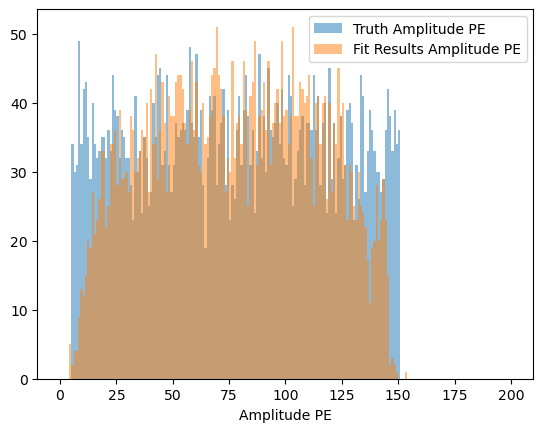

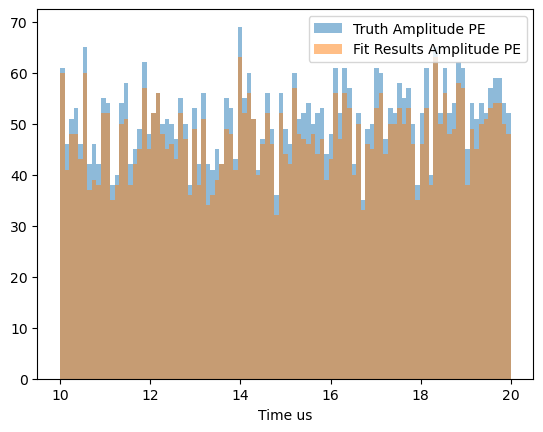

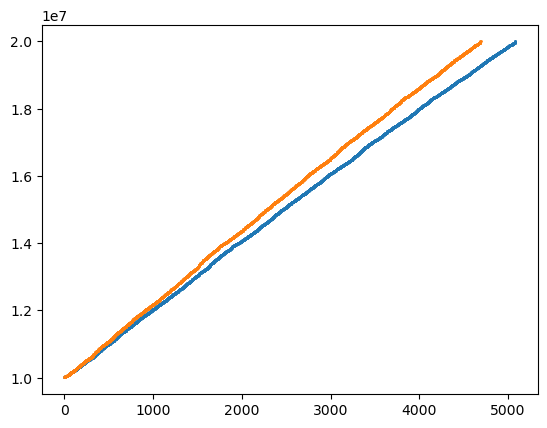

Truth time: 10004808.42 us, Fit time: 10004812.92 us
Truth time: 10009480.80 us, Fit time: 10009485.30 us
Truth time: 10014250.32 us, Fit time: 10014254.82 us
Truth time: 10014809.91 us, Fit time: 10014814.41 us
Truth time: 10014982.78 us, Fit time: 10014987.28 us
Truth time: 10017888.10 us, Fit time: 10017892.60 us
Truth time: 10020708.02 us, Fit time: 10020712.53 us
Truth time: 10026956.62 us, Fit time: 10026961.12 us
Truth time: 10027115.20 us, Fit time: 10027119.71 us
Truth time: 10029208.33 us, Fit time: 10029213.13 us
Truth time: 10029349.20 us, Fit time: 10029353.77 us
Truth time: 10031527.25 us, Fit time: 10034994.41 us
Truth time: 10034989.90 us, Fit time: 10035768.20 us
Truth time: 10035763.69 us, Fit time: 10038231.62 us
Truth time: 10038226.86 us, Fit time: 10038538.91 us
Truth time: 10038534.41 us, Fit time: 10038722.06 us
Truth time: 10038717.56 us, Fit time: 10039352.42 us
Truth time: 10039347.92 us, Fit time: 10041154.82 us
Truth time: 10041150.32 us, Fit time: 10041980

In [81]:
pe_bins = np.linspace(0, 200, 201)
plt.hist(truth['amplitude_pe'], bins=pe_bins, alpha=0.5, label='Truth Amplitude PE')
plt.hist(fit_results['amplitude_pe'] * (np.mean(truth['amplitude_pe']) / np.mean(fit_results['amplitude_pe'])), bins=pe_bins, alpha=0.5, label='Fit Results Amplitude PE')
plt.legend()
plt.xlabel('Amplitude PE')
plt.show()

t_bins = np.linspace(10, 20, 100)
plt.hist(truth['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Truth Amplitude PE')
plt.hist(fit_results['time_us'] / 1e6, bins=t_bins, alpha=0.5, label='Fit Results Amplitude PE')
plt.legend()
plt.xlabel('Time us')
plt.show()

plt.scatter(range(len(truth['time_us'])), truth['time_us'], s=1)
plt.scatter(range(len(fit_results['time_us'])), fit_results['time_us'], s=1)
plt.show()

for i, j in zip(truth['time_us'], fit_results['time_us']):
    print(f"Truth time: {i:.2f} us, Fit time: {j:.2f} us")